# 04 — Explainability (XAI) Deep Dive

Trains a small HydroSense-Base model on the synthetic corpus and walks through the full explainability stack (README §11): Grad-CAM, the acoustic sanity check, and SHAP per-band attribution.

As in `03_timegan_validation.ipynb`, epoch counts are kept small for notebook runtime — this is a **mechanics walkthrough**, not a benchmark run. Training and inference both shell out to the real CLI modules (`src.training.train`, `src.xai.explain`) so the code path exercised here is identical to production use.

In [1]:
import os
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root (pyproject.toml not found)")


REPO_ROOT = _find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Working directory: {REPO_ROOT}")


Working directory: Z:\hydrosense


In [2]:
import json
import shutil
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

from src.data.synthetic import generate_synthetic_dataset

WORK_DIR = REPO_ROOT / "notebooks" / ".tmp_nb04"
RAW_DIR = WORK_DIR / "raw"
PROCESSED_DIR = WORK_DIR / "processed"
SPLITS_DIR = WORK_DIR / "splits"
RUN_DIR = WORK_DIR / "runs" / "hydrosense_base_mel"
EXPLAIN_DIR = WORK_DIR / "explanations"


def run(*args: str) -> None:
    print("$ python -m", " ".join(args))
    subprocess.run([sys.executable, "-m", *args], cwd=REPO_ROOT, check=True)


## Step 1 — synthetic corpus + preprocessing

In [3]:
if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)

records = generate_synthetic_dataset(
    output_dir=RAW_DIR,
    recordings_per_class={"A": 6, "B": 8, "C": 10, "D": 5, "E": 4},
    duration_range_s=(20.0, 40.0),
    sample_rate=16000,
    seed=42,
)
pd.DataFrame(records).to_csv(RAW_DIR / "metadata.csv", index=False)

run(
    "src.preprocessing.run",
    "--input_dir", str(RAW_DIR),
    "--output_dir", str(PROCESSED_DIR),
    "--splits_dir", str(SPLITS_DIR),
    "--sr", "16000",
    "--segment_length", "10.0",
    "--overlap", "0.5",
    "--representation", "mel",
    "--n_folds", "2",
)


$ python -m src.preprocessing.run --input_dir Z:\hydrosense\notebooks\.tmp_nb04\raw --output_dir Z:\hydrosense\notebooks\.tmp_nb04\processed --splits_dir Z:\hydrosense\notebooks\.tmp_nb04\splits --sr 16000 --segment_length 10.0 --overlap 0.5 --representation mel --n_folds 2


## Step 2 — train HydroSense-Base (2 folds, 3 epochs — mechanics only)

In [4]:
run(
    "src.training.train",
    "--model", "hydrosense_base",
    "--representation", "mel",
    "--processed_dir", str(PROCESSED_DIR),
    "--folds", "2",
    "--epochs", "3",
    "--batch_size", "8",
    "--max_folds_to_run", "1",
    "--output_dir", str(RUN_DIR),
)


$ python -m src.training.train --model hydrosense_base --representation mel --processed_dir Z:\hydrosense\notebooks\.tmp_nb04\processed --folds 2 --epochs 3 --batch_size 8 --max_folds_to_run 1 --output_dir Z:\hydrosense\notebooks\.tmp_nb04\runs\hydrosense_base_mel


## Step 3 — full XAI report for one clip (Grad-CAM + acoustic sanity check + SHAP)

In [5]:
sample_audio = sorted((RAW_DIR).glob("A_*.wav"))[0]

run(
    "src.xai.explain",
    "--checkpoint", str(RUN_DIR / "best.ckpt"),
    "--audio_file", str(sample_audio),
    "--output_dir", str(EXPLAIN_DIR),
    "--processed_dir", str(PROCESSED_DIR),
    "--n_shap_background", "10",
)


$ python -m src.xai.explain --checkpoint Z:\hydrosense\notebooks\.tmp_nb04\runs\hydrosense_base_mel\best.ckpt --audio_file Z:\hydrosense\notebooks\.tmp_nb04\raw\A_000.wav --output_dir Z:\hydrosense\notebooks\.tmp_nb04\explanations --processed_dir Z:\hydrosense\notebooks\.tmp_nb04\processed --n_shap_background 10


In [6]:
with (EXPLAIN_DIR / "prediction.json").open() as f:
    prediction = json.load(f)
prediction


{'predicted_class': 'C',
 'top3': [{'class_name': 'C', 'confidence': 0.21888718008995056},
  {'class_name': 'E', 'confidence': 0.20001506805419922},
  {'class_name': 'D', 'confidence': 0.19949409365653992}]}

### Grad-CAM overlay (README §11.1)

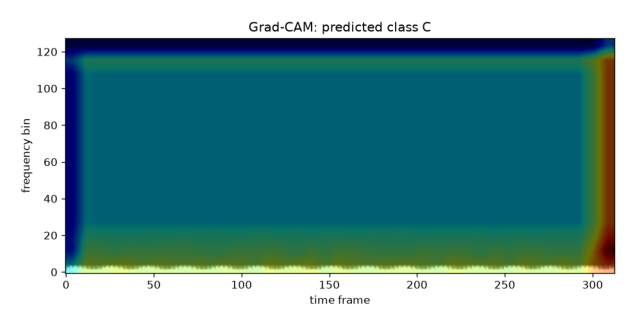

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(plt.imread(EXPLAIN_DIR / "gradcam_overlay.png"))
ax.axis("off")
plt.show()


### Acoustic sanity check (README §11.3)

In [8]:
with (EXPLAIN_DIR / "spectral_peaks.json").open() as f:
    sanity = json.load(f)
sanity


{'harmonic_series_detected': False}

### SHAP per-band attribution (README §11.2)

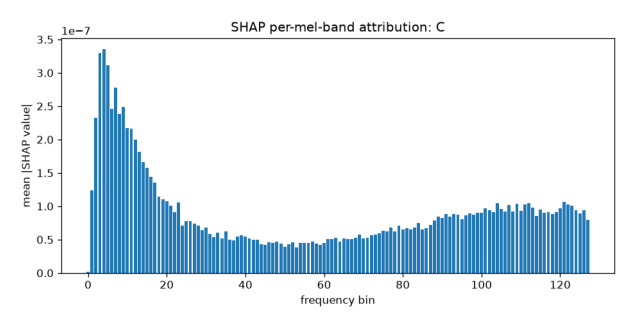

In [9]:
shap_bar_path = EXPLAIN_DIR / "shap_bar.png"
if shap_bar_path.exists():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(plt.imread(shap_bar_path))
    ax.axis("off")
    plt.show()
else:
    print("SHAP was skipped (not enough training segments for a background set)")


## Observations

- With only 3 training epochs the classifier is far from converged — the point of this notebook is to demonstrate that every stage of the XAI stack (Grad-CAM -> acoustic sanity check -> SHAP) runs end-to-end and produces artifacts consistent with what `app/streamlit_app.py` shows interactively (README §12), not to produce a trustworthy explanation.
- For a real analysis, point `--checkpoint` at a fully-trained run (README §14 training numbers) and re-run Step 3 directly.
- `notebooks/.tmp_nb04/` is a scratch directory (gitignored) — safe to delete and re-run.